In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpoint , ChatHuggingFace
from langchain.messages import RemoveMessage

In [4]:
load_dotenv()

True

In [5]:
llm1 = HuggingFaceEndpoint(repo_id="Qwen/Qwen2.5-7B-Instruct")
model = ChatHuggingFace(llm=llm1)

In [6]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [7]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [8]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [9]:
graph = builder.compile(checkpointer=InMemorySaver())

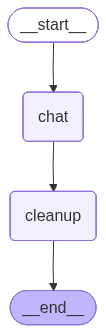

In [10]:
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

In [12]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Shubham"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='de9b5f88-6666-409c-8b79-cd4f32d880a3'),
  AIMessage(content='LangChain is a framework designed to help build applications that integrate with large language models (LLMs) like LangGraph. It provides a set of tools and libraries to enable developers to easily create, deploy, and manage applications that utilize the capabilities of LLMs. LangChain is built on top of existing libraries and frameworks, often using popular tools like PyTorch, Hugging Face Transformers, and others.\n\nHere are some key aspects of LangChain:\n\n### Key Features and Components\n\n1. **Modular Design**:\n   - LangChain is designed to be modular, allowing developers to easily integrate different components and libraries.\n   - This modularity makes it flexible and adaptable to various use cases and requirements.\n\n2. **Tooling and Utilities**:\n   - **Tokenization and Data Processing**: LangChain provides uti

In [13]:

snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
